<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [ ]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [1]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 35.4 MB/s eta 0:00:00


In [ ]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [ ]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [ ]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [ ]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?
2. ¿Cuántos canales tiene?
3. ¿Cómo se llama el canal seleccionado?
4. ¿Cuál es la duración total del registro?
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?


Respuestas
1. 360 Hz
2. 2
3. MLII
4. 18.5.56 segundos
5. 360 muestras
6. 3600 muestras


## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [ ]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [ ]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [ ]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


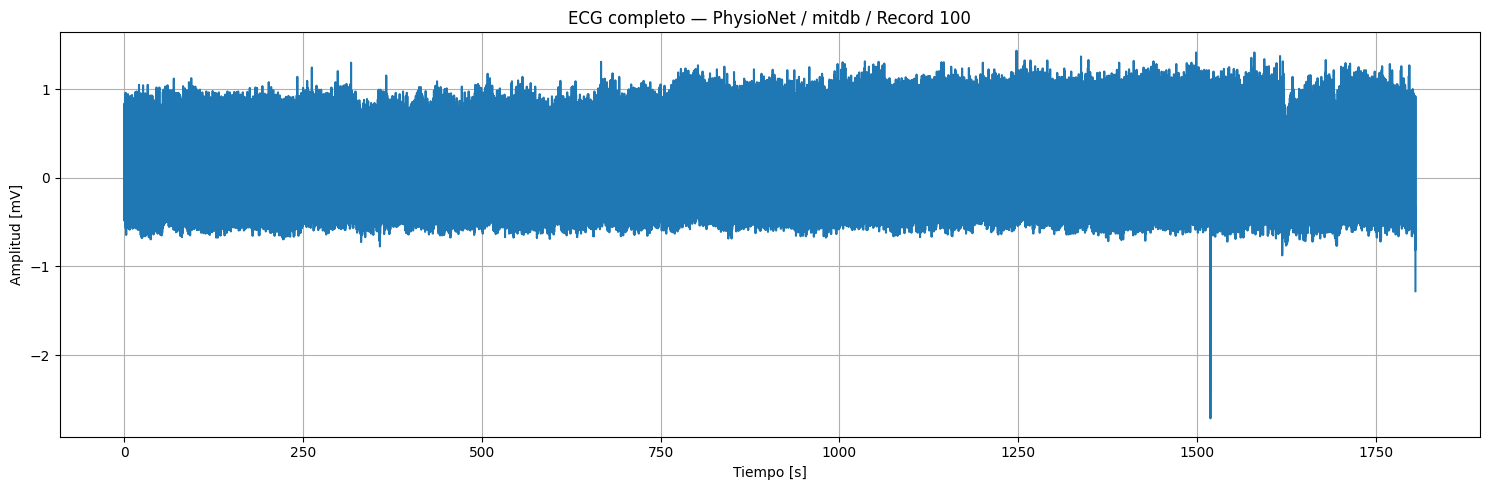

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
2. ¿Se pueden identificar visualmente complejos QRS?
3. ¿La morfología permanece igual durante todo el registro?
4. ¿Se observa ruido?
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?


Respuestas
1. No, la amplitud varía a lo largo del registro.
2. No debido a que la gráfica esta mostrando aproximadamente 30 minutos de señal
3. No se observa en esta gráfica
4. Si, cerca de los 1500 segundos se observa una caida abrupta
5. Permite observar el comportamiento global del ECG
6. No se puede observar a detalle ni identificar ninguna onda del electrocardiograma



# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [ ]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


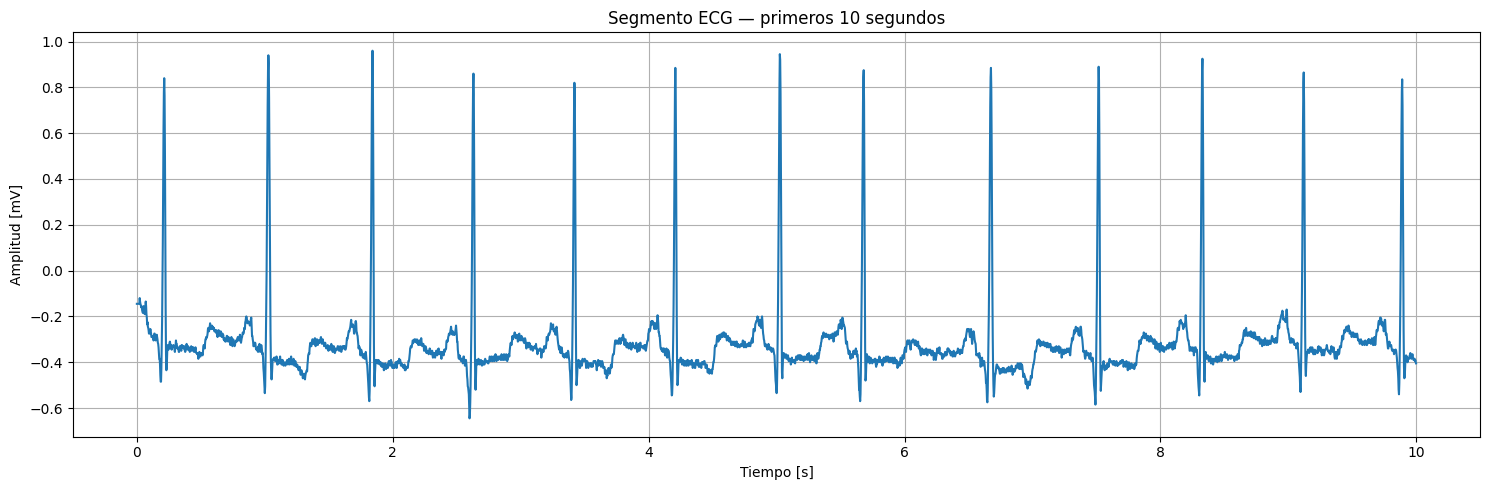

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


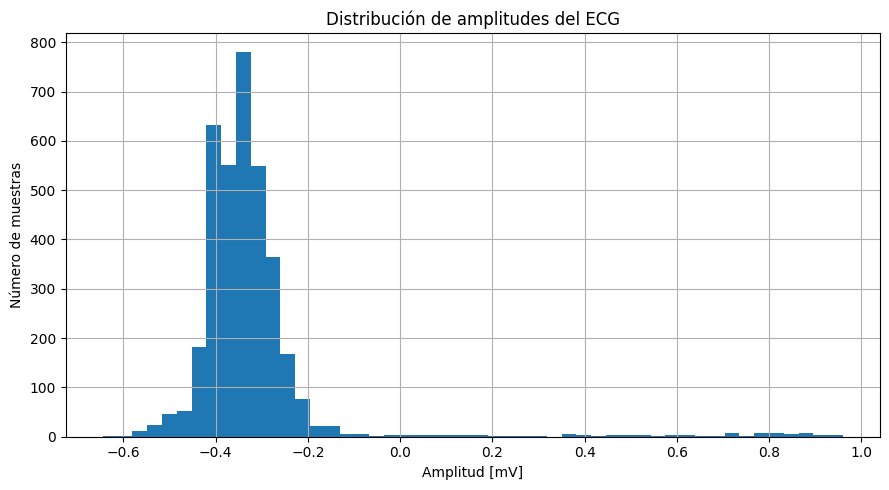

In [ ]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?
2. ¿La distribución parece simétrica?
3. ¿Existen valores extremos?
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
5. ¿El histograma conserva información temporal? Explique.


1. Entre −0.45 mV y −0.25 mV
2. No debido a que hay valores cercanos a 1 mV y no hay esa distribución en los valores negativos
3. Existen valores cercanos a 1 mV
4. Pueden ser perturbaciones en la medición
5. No debido a que no muestra en que momento aparece cada rango de amplitud


# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


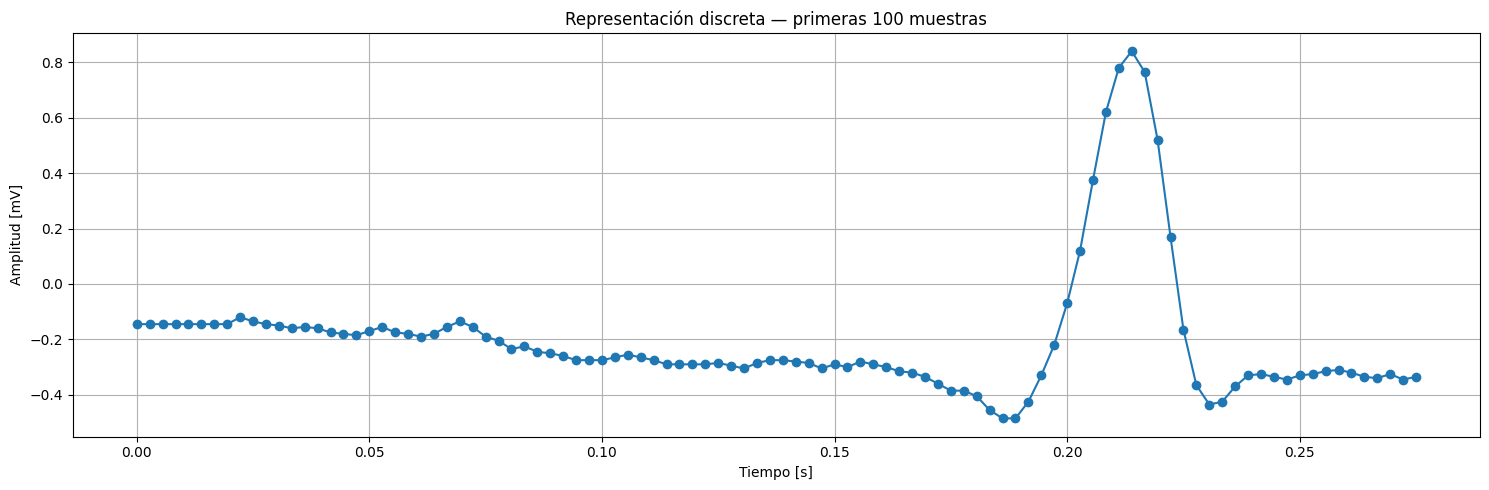

In [ ]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?
2. ¿Qué ocurre si aumentamos `fs`?
3. ¿Qué ocurre si disminuimos `fs`?
4. ¿Qué representa el eje `n` en una señal discreta?
5. ¿Cuál es la relación entre `n`, `fs` y `t`?


Respuestas
1. 360 muestras por segundo
2. Habrian más muestras por la misma cantidad de tiempo por lo que los puntos estarian mas juntos
3. Habrian menos muestras por la misma cantidad de tiempo y puede que se llegue a perder informacion si no se cumple con el teorema de Nyquist
4. El número de muestras
5. t = n/fs


# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [ ]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [ ]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [ ]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [ ]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?
2. ¿El sonido corresponde a un sonido fisiológico real?
3. ¿Por qué un ECG puede convertirse a WAV?
4. ¿Qué información se conserva al hacer la conversión?
5. ¿Qué información fisiológica podría perderse al escucharla?
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?


Respuestas:
1. No se escucha claramente
2. No debido a que el ECG mide el la actividad eléctrica del corazon mas no el sonido que este produce.
3. Porque ambos están formados por muestras de amplitud ordenadas en el tiempo.
4. Se conserva el orden temporal de las muestras, la frecuencia de muestreo, las variaciones de amplitud.
5. Seria dificil identificar las ondas p, QRS y T, ademas que tampoco podria identificarse la amplitud exacta ni la duración de cada intervalo.
6. La representación grafica permite identificar los datos que se mencionaron en la pregunta 5 que serian dificiles de identificar en WAV.



# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [ ]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?

---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.


**Ejercicio 1**

In [ ]:
import wfdb

registros = wfdb.get_record_list('mitdb')
print(registros)

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


Registro: 115
Frecuencia: 360
Número de muestras: 650000
Número de canales: 2
Canales: ['MLII', 'V1']
Unidades: ['mV', 'mV']


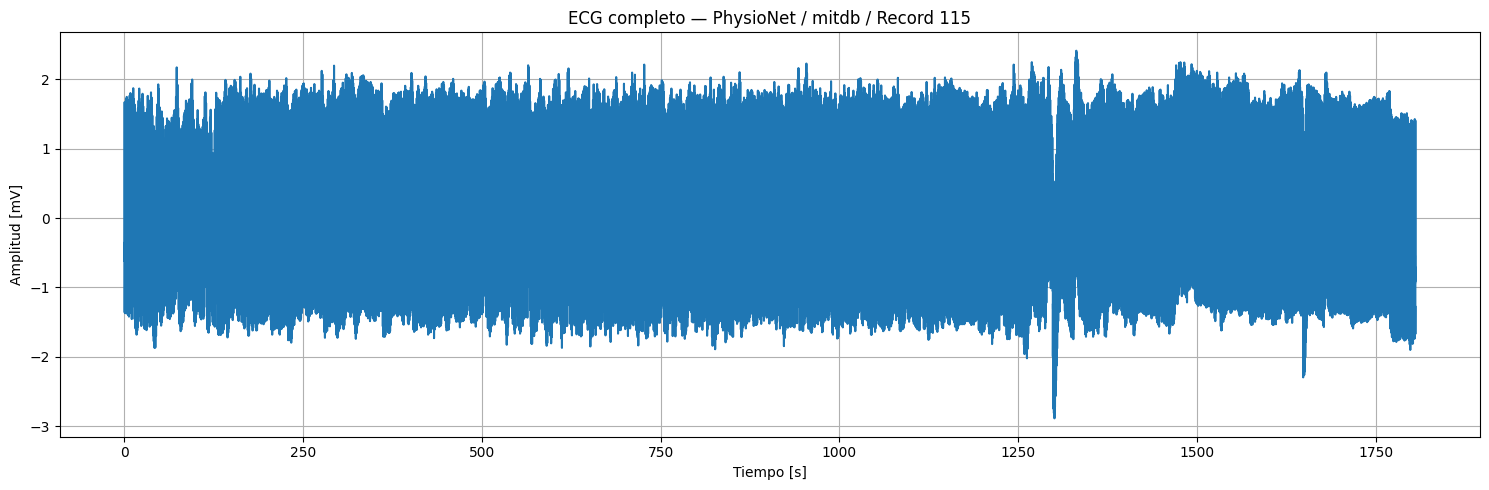

In [ ]:

import wfdb

RECORD_3 = "115"
DATABASE_3 = "mitdb"
CHANNEL_3 = 0

record3 = wfdb.rdrecord(RECORD_3, pn_dir=DATABASE_3)

fs3 = record3.fs
signal3 = record3.p_signal
channels3 = record3.sig_name
units3 = record3.units

print("Registro:", RECORD_3)
print("Frecuencia:", fs3)
print("Número de muestras:", record3.sig_len)
print("Número de canales:", record3.n_sig)
print("Canales:", channels3)
print("Unidades:", units3)

t3 = np.arange(len(signal3)) / fs3

plt.figure(figsize=(15, 5))
plt.plot(t3, signal3[:, CHANNEL_3])
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record3.units[CHANNEL_3]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE_3} / Record {RECORD_3}"
)
plt.grid(True)
plt.tight_layout()
plt.show()


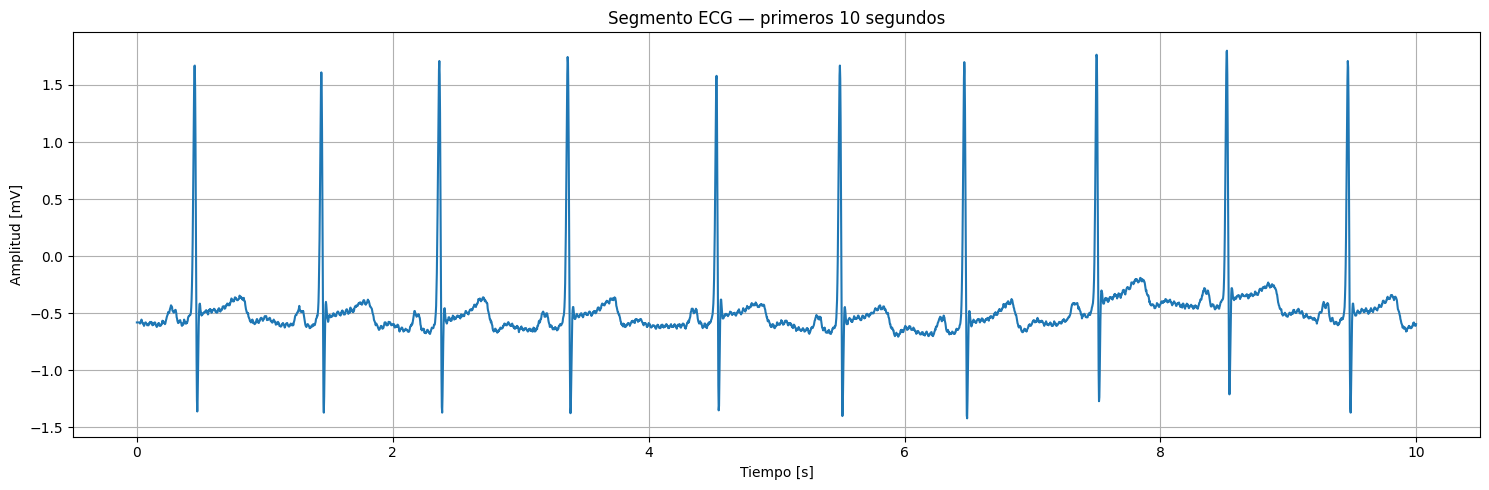

In [ ]:
# ============================================
# SELECCIONAR SEGMENTO
# ============================================

DURATION_3 = 10  # segundos
N3 = int(DURATION_3 * fs3)
signal_segment_3 = signal3[:N3]
t_segment_3 = t3[:N3]

plt.figure(figsize=(15, 5))
plt.plot(
    t_segment_3,
    signal_segment_3[:, CHANNEL_3]
)
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record3.units[CHANNEL_3]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION_3} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

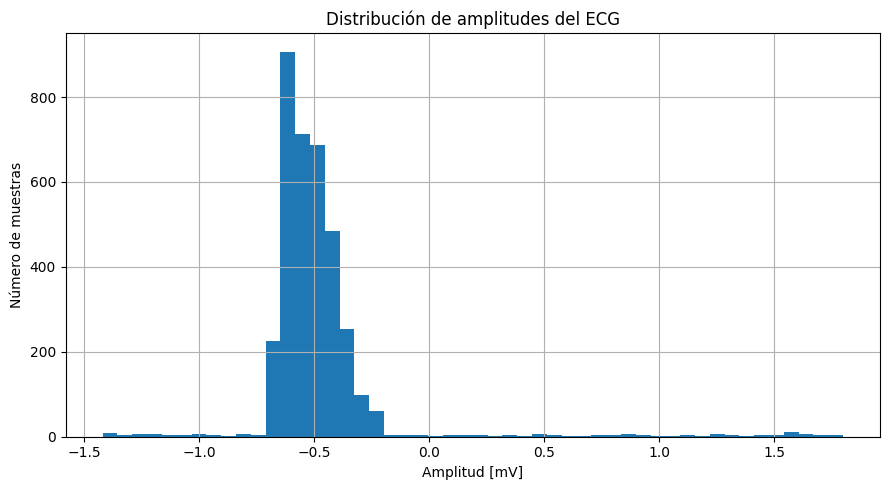

In [ ]:
# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))
plt.hist(
    signal_segment_3[:, CHANNEL_3],
    bins=50
)

plt.xlabel(f"Amplitud [{record3.units[CHANNEL_3]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")
plt.grid(True)
plt.tight_layout()
plt.show()


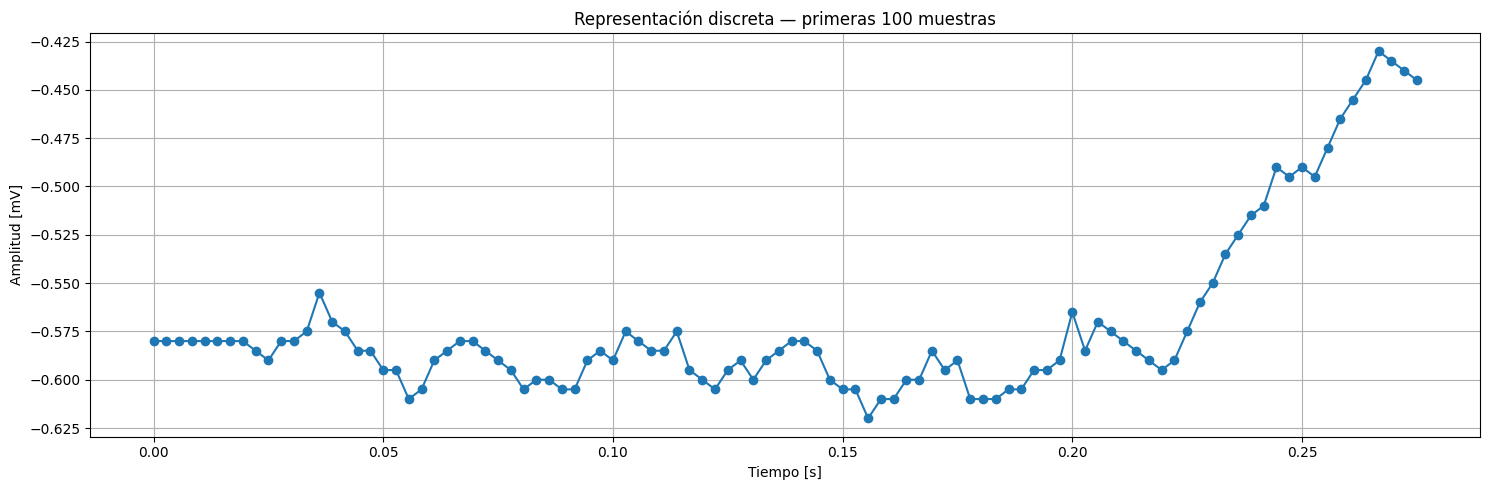

In [ ]:
# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES_3 = 100
plt.figure(figsize=(15, 5))
plt.plot(
    t_segment_3[:N_SAMPLES_3],
    signal_segment_3[:N_SAMPLES_3, CHANNEL_3],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record3.units[CHANNEL_3]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES_3} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

Comparación con el registro original
En la primera gráfica se observa una caida abrupta cerca a los 1300 segundos que puede deberse a ruido
En la grafica dos se observa una cantidad menor del complejo QRS en el mismo tiempo (10 segundos) lo que significa una frecuencia cardiaca promedio menor en este registro
En la tercera gráfica se observa valores en los extremos -1.5 mv  y 1.5 mv a diferencia del registro original. Aunque en ambos registros siguen siendo asimietricos.
En la última gráfica no se observa un pico QRS claramente definido dentro de este intervalo y la señal está desplazada hacia valores más negativos que en el registro original.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

### a)

Calcule el periodo de muestreo:

\[
T_s = \frac{1}{f_s}
\]

RPTA: Ts = 1/360 = 0.0027778 segundos

### b)

¿Cuántas muestras existen en 5 segundos?

RPTA: N = 360*5 = 1800 muestras

### c)

¿Cuántas muestras existen en 10 segundos?

RPTA: N= 3600 muestras

### d)

Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.

RPTA: Si no cumple con el teorema de Nyquist se puede perder información importante y asi dificultando la identificación de detalles como los complejos QRS

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.


In [ ]:
# ============================================
# ESTADÍSTICAS DEL SEGMENTO
# ============================================

mean_value_3 = np.mean(signal_segment_3[:, CHANNEL_3])
std_value_3 = np.std(signal_segment_3[:, CHANNEL_3])
min_value_3 = np.min(signal_segment_3[:, CHANNEL_3])
max_value_3 = np.max(signal_segment_3[:, CHANNEL_3])

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media               : {mean_value_3:.4f}")
print(f"Desviación estándar : {std_value_3:.4f}")
print(f"Mínimo              : {min_value_3:.4f}")
print(f"Máximo              : {max_value_3:.4f}")
print(f"Rango                : {max_value_3 - min_value_3:.4f}")

ESTADÍSTICAS DEL SEGMENTO
Media               : -0.4823
Desviación estándar : 0.2973
Mínimo              : -1.4200
Máximo              : 1.8000
Rango                : 3.2200


El número mas alto de mV que tiene la señal es de 1.8 mV y el menor valor es de -1.42 mV, esto suma un rango de 3.22 mV en toda la señal. El valor de media de -0.4823 indica que la señal esta centrada en valores negativos y la desviación indica que hay una variabilidad de 0.3 mV aproximadamente respecto al valor medio.


# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

El PhysioNet es una plataforma gratuita que proporciona acceso a bases de datos de señales fisiológicas y clínicas , como por ejemplo:
Electrocardiogramas (ECG)
Electroencefalogramas (EEG)
Electromiogramas (EMG)
Presión arterial
Respiración y saturación de oxígeno
Esta herramienta permite visualizar y analizar estas señales


### 2.
¿Qué diferencia existe entre `DATABASE` y `RECORD`?

Database: Es una colección organizada de información biomédica que reúne varios pacientes, estudios o registros.
Record: Es una unidad individual dentro de una base de datos. Generalmente contiene las señales correspondientes a un paciente o una sesión de medición, junto con sus archivos asociados

### 3.
¿Qué representa `fs`?

Representa la frecuencia de muestreo con la que se digitaliza la señal, en otras palabras cuantas muestras se toman por segundo.

### 4.
¿Qué representa `CHANNEL`?

El canal que se desea seleccionar y analizar.

### 5.
¿Qué representa `record.p_signal`?

Guarda las muestras de todos los canales en una matriz.

### 6.
¿Por qué necesitamos construir un eje temporal?

Para relacionar cada muestra con un instante en el que fue adquirido y lograr analizar la señal en función de tiempo.

### 7.
¿Qué diferencia existe entre una señal continua y una señal discreta?

Una señal continua muestra todos los datos en todo el instante de tiempo de la señal y una señal discreta selecciona muestras de la señal en instantes de tiempos determinados determinados por una frecuencia de muestreo.

### 8.
¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

Porque un archivo WAV almacena muestras de audio no garantiza que sus amplitudes, unidades, canales y frecuencia de muestreo correspondan a una señal electrocardiográfica.   

### 9.
¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

Una señal sintetica simula aproximadamente una señal biológica y puede ser util para probar algoritmos debido a que son mas controladas sin embargo si se quiere estudiar datos representativos es mejor realizarlo con señales biomédicas.

### 10.
¿Qué dificultades encontró durante el laboratorio?

Entender algunas partes del código enseñado.



# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.



# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
